![Logo](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/shared_assets/logo.png)

**Developers:** Zoltan Barta  
**Date:** 2026-04-05  
**Version:** 2025-26/2

[<img src="https://colab.research.google.com/assets/colab-badge.svg">](https://colab.research.google.com/github/BartaZoltan/deep-reinforcement-learning-course/blob/main/notebooks/sessions/7_dqn/dqn.ipynb)

# Practice 7: Deep Q-Networks and Double DQN

## Summary

In Practice 6, the action-value function was still represented by a simple linear model on top of hand-designed features. In this session, the same Bellman-learning idea is pushed to a much harder setting: raw Atari frames. The main goal is to build a working `DQN` pipeline on `Pong`, then refine only the target computation and arrive at `Double DQN`.

This notebook follows one coherent progression:
- Atari preprocessing on `ALE/Pong-v5`,
- experience replay and a convolutional Q-network,
- DQN targets with replay and a target network,
- a full training loop on Pong,
- Double DQN as the first stabilizing improvement.

The conceptual shift is that the value function no longer receives a compact hand-crafted state representation. Instead, the network must learn directly from stacked image frames.


## From Linear Action Values to Deep Q-Networks

The core reinforcement learning object stays the same:

$$
q(s,a)
$$

What changes is the representation of the state. In Atari, the agent does not observe a small feature vector such as position and velocity. It observes image frames. That means the approximation now has to solve two problems at once: it must learn useful visual features and it must assign good action values on top of them.

A plain neural-network version of Q-learning is typically unstable. Consecutive frames are highly correlated, targets keep changing as the network changes, and the max operator can amplify estimation errors. The original DQN paper addressed this with two mechanisms that define the whole method: **experience replay** and a **target network**.

## Session Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.util
import urllib.request

import numpy as np

try:
    import gymnasium as gym
except Exception:
    gym = None

try:
    import ale_py
except Exception:
    ale_py = None

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
except Exception:
    torch = None
    nn = None
    F = None
    optim = None

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


def _load_session7_utils():
    candidates = [
        Path('utils.py'),
        Path('notebooks/sessions/7_dqn/utils.py'),
        Path('/content/notebooks/sessions/7_dqn/utils.py'),
    ]

    utils_path = next((p for p in candidates if p.exists()), None)
    if utils_path is None:
        utils_path = Path('notebooks/sessions/7_dqn/utils.py')
        utils_path.parent.mkdir(parents=True, exist_ok=True)
        url = (
            'https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/'
            'notebooks/sessions/7_dqn/utils.py'
        )
        urllib.request.urlretrieve(url, utils_path)

    spec = importlib.util.spec_from_file_location('session7_utils', utils_path)
    module = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(module)
    return module


s7u = _load_session7_utils()
SEED = 42
GLOBAL_RNG = s7u.set_seed(SEED)
DEVICE = s7u.select_device()
ASSET_ROOT = s7u.resolve_asset_root('notebooks/sessions/7_dqn')

print('Device:', DEVICE)

Device: mps


## Environment and Preprocessing

In Atari, the agent does not observe a small structured state such as position and velocity. It observes raw game frames. For `Pong`, this means that the input is initially a full RGB image stream coming directly from the emulator.

In principle, we could try to feed these raw frames directly into the network. In practice, that is usually unnecessary and inefficient. Much of the raw image is either redundant or only weakly relevant to the control problem. Preprocessing is therefore not just a convenience step: it is part of how we make deep value-based learning tractable.

The main idea is to keep the visually important information while removing parts of the input that make learning harder without adding much value. Frame skipping reduces the number of decisions and removes some temporal redundancy. Grayscale conversion removes color information that is usually not essential in Pong. Cropping focuses the representation on the active game area. Resizing compresses the image into a fixed compact resolution. Finally, frame stacking restores short-term motion information that would be missing from a single still image.

So the goal of preprocessing is not to distort the problem, but to present it to the network in a cleaner and more learnable form. The agent still has to solve the same control task, but now from an observation that is smaller, more structured, and better aligned with what matters for decision-making.


In some reinforcement learning environments, an alternative low-dimensional state representation is available in addition to image observations. Instead of feeding the agent rendered frames, the environment may expose a compact feature vector containing internal state variables such as positions, velocities, object coordinates, or even RAM values in emulator-based settings.

This can be very useful in practice. A structured state vector is usually smaller, cheaper to process, and easier to learn from than raw images. It is often the right choice when the goal is to study control or compare algorithms without also taking on the separate challenge of visual representation learning.

The general pattern looks like this: one version of the environment returns rendered observations such as RGB frames, while another version returns a compact state vector. If such a version exists, it is often worth checking because it can greatly simplify experimentation.

In this session, however, we will stay with the image-based version. The point of DQN is not only that it learns action values, but that it learns them from visual observations through a deep network. So even though lower-dimensional alternatives are sometimes available, here we intentionally keep the RGB-to-preprocessed-image pipeline and treat visual input as part of the problem itself.


### Environment: Pong-v5

`ALE/Pong-v5` is one of the classic Atari control problems used in the original DQN work. The raw environment produces full RGB emulator frames with shape `210 x 160 x 3`, so the state is no longer a compact vector of hand-designed features but a visual scene containing the paddles, the ball, and the scoreboard. After preprocessing, the agent will not see the full RGB frame any more. Instead, it will act from a stack of four grayscale `84 x 84` images.

The action space is discrete. In the reduced Pong action set, the most important behaviors are simply the paddle movements and the `FIRE` action that starts play. Even so, the network still has to connect local paddle motions to delayed point outcomes, which is much harder than the low-dimensional control problems in the previous practices.

The reward structure is sparse and game-based: the agent receives `+1` when it wins a point and `-1` when it loses one. That makes Pong a clean value-based benchmark, because successful control is not about immediate dense rewards but about learning long chains of visually grounded actions that eventually win rallies.


In the wrapped environment used for training and evaluation, reset also performs the initial `FIRE` action. This is a small Atari-specific detail, but it matters: otherwise a greedy policy can spend its first steps doing nothing before the game has actually started.

### Example Pong gameplay

Before looking at preprocessing, it helps to see what the game itself looks like. The GIF below is only a short example rollout, not a learned agent. Its role is to make the environment concrete: two paddles, one ball, sparse point-based rewards, and long stretches of movement before any reward arrives.


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Example Pong gameplay: {'gif_path': 'assets/cell_outputs/pong_example_gameplay.gif', 'total_return': 0.0, 'steps_executed': 240}



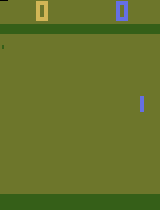

In [2]:
example_pong_gif = s7u.export_sample_pong_gameplay_gif(
    output_dir=ASSET_ROOT,
    gif_name='pong_example_gameplay.gif',
    seed=SEED,
    max_steps=240,
    fps=20.0,
)

print('Example Pong gameplay:', example_pong_gif)
display(s7u.render_side_by_side_gifs([{'title': 'Example Pong gameplay', 'gif_path': example_pong_gif['gif_path']}], width=460))

### Building the DQN observation step by step

The final DQN input is not one raw Pong frame. It is the result of several preprocessing choices made for computational and learning reasons. In the next few blocks, we unpack these steps one at a time: frame skipping, grayscale conversion, cropping, resizing, and finally frame stacking. The point is to see not just *what* the input looks like at the end, but *why* we transform the raw game image in the first place.


In [3]:
preprocessing_reference = s7u.prepare_pong_preprocessing_reference(
    seed=SEED,
    frame_skip=4,
    stack_size=4,
    screen_size=84,
    warmup_steps=8,
    crop_rows=(34, 194),
    crop_cols=(0, 160),
)

print('Frame skip:', preprocessing_reference['frame_skip'])
print('Crop rows:', preprocessing_reference['crop_rows'])
print('Crop cols:', preprocessing_reference['crop_cols'])
print('Resize target:', preprocessing_reference['resized_frame'].shape)
print('Final stacked shape:', preprocessing_reference['stacked_obs'].shape)

Frame skip: 4
Crop rows: (34, 194)
Crop cols: (0, 160)
Resize target: (84, 84)
Final stacked shape: (4, 84, 84)


### Step 1: Frame skipping

Atari runs at a much finer temporal resolution than the agent needs for every single decision. With frame skipping, the same chosen action is repeated for several emulator frames. This reduces computation and makes the control problem less twitchy. The important point is that the agent does not receive every raw frame as a separate learning target.


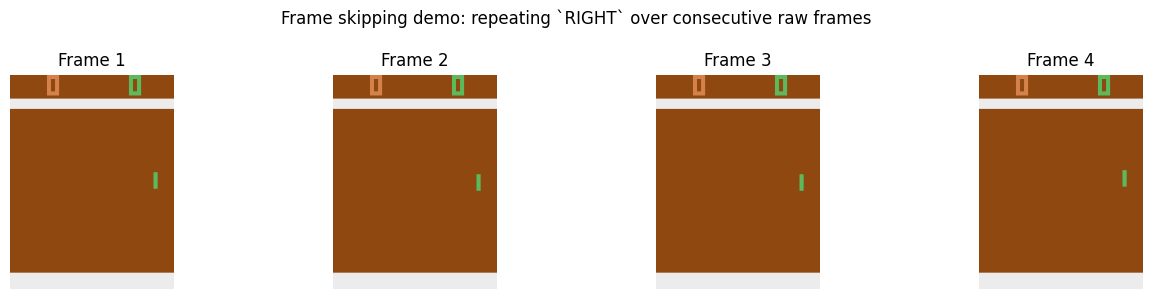

In [4]:
s7u.plot_pong_frame_skip_showcase(preprocessing_reference)

### Step 2: Grayscale conversion

Color is usually not the important part of the Pong state. What matters is where the ball and paddles are and how they move. Converting the raw RGB frame to grayscale removes redundant color information and gives the network a simpler visual input to model.


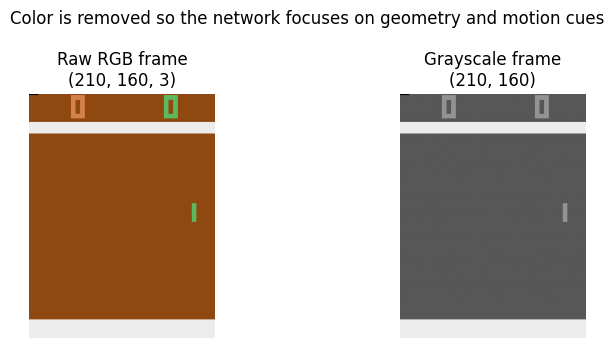

In [5]:
s7u.plot_pong_grayscale_showcase(preprocessing_reference)

### Step 3: Crop the play area

The raw Atari frame contains borders and screen regions that matter much less than the active game area. Cropping focuses the representation on the part of the image where the paddles and ball actually interact. This is a simple way to spend model capacity on the relevant geometry instead of wasted pixels.


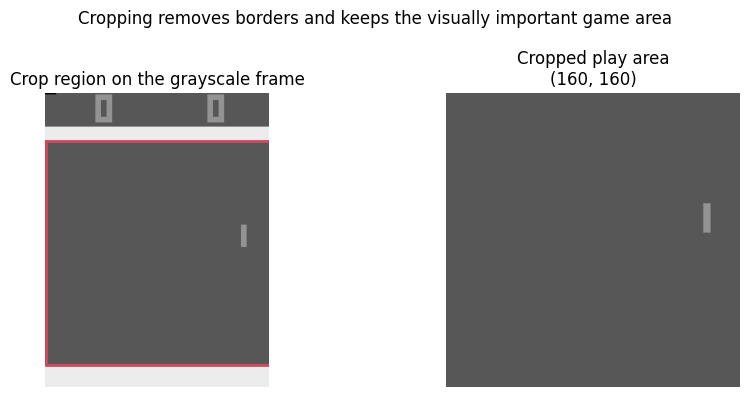

In [6]:
s7u.plot_pong_crop_showcase(preprocessing_reference)

### Step 4: Resize to `84 x 84`

Even after cropping, the frame is still much larger than necessary for value-based control. Resizing compresses the image into a compact fixed resolution that is small enough for efficient convolutional processing, while still preserving the basic structure of the paddles, the ball, and their relative positions.


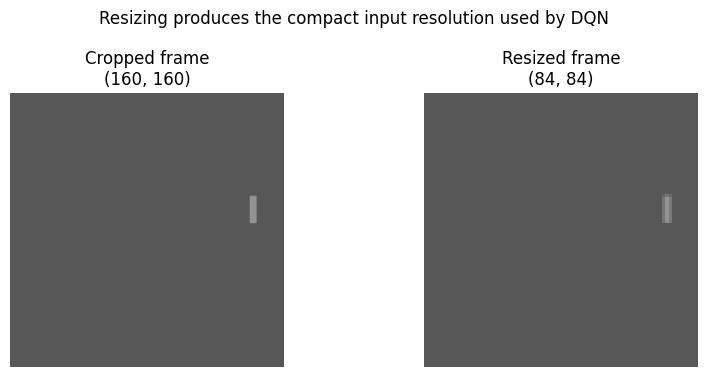

In [7]:
s7u.plot_pong_resize_showcase(preprocessing_reference)

### Step 5: Stack the latest processed frames

A single processed image still has one important limitation: it does not tell us which direction the ball is moving. Frame stacking fixes this by giving the network the last few processed observations together. Now motion becomes visible through short-term changes across the stack, which is exactly the information the Q-network needs for control.


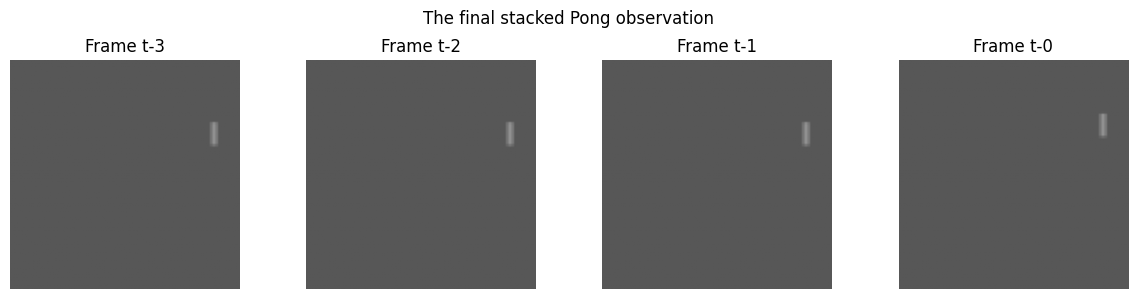

In [8]:
s7u.plot_pong_stack_showcase(preprocessing_reference)

## Experience Replay and Convolutional Q-Networks

At a high level, DQN keeps the same core learning idea as Q-learning. We still want to learn an action-value function

$$
Q(s,a)
$$

and we still update it toward a Bellman target built from reward and a bootstrapped estimate of the next state. What changes is the representation of that value function. In tabular Q-learning, every state-action pair has its own separate entry in a table. In DQN, we replace that table with a deep neural network

$$
Q(s,a;\theta),
$$

where the parameters `theta` are shared across all states and actions.

This change is powerful, because it allows us to work in settings where a table is no longer realistic, such as image-based Atari environments. The network can take a high-dimensional observation as input and produce one Q-value per action. In that sense, DQN is simply Q-learning with a deep function approximator.

At the same time, this is exactly where the difficulty begins. A neural network is not updated locally the way a table is. In a table, changing one state-action value only affects that one entry. In a neural network, every update changes shared parameters, so it can influence the predictions of many states at once. This makes the learning process much less stable.

A second issue is that reinforcement learning data does not arrive in the way standard supervised learning expects it. Consecutive transitions are highly correlated, because they come from one continuous trajectory rather than from independent trajectories or randomized examples. If we train directly on these back-to-back samples, the network repeatedly sees nearly the same local situation. That makes optimization noisy and inefficient, and it breaks the usual assumption that training examples are approximately independent.

A third difficulty is that the target itself is moving. In supervised learning, the target labels are fixed. In Q-learning with a neural network, the target contains a value estimate produced by the current network or by a closely related network. So while the model is trying to fit the target, the target is also changing. This feedback loop can easily make the updates unstable.

These are the two classic engineering fixes that define DQN.

First, we use a **replay buffer**. Instead of training immediately on the newest transition, we store transitions in a large memory and later sample random minibatches from it. This helps in two ways: it breaks the short-range temporal correlation of trajectory data, and it lets the same experience be reused multiple times across different updates. In effect, the replay buffer makes reinforcement learning data look a bit more like the randomized data stream used in supervised learning.

Second, we use a **target network**. The online network is the one we update at every optimization step, but the Bellman target is computed with a separate copy whose parameters are updated only periodically. This slows down the movement of the target and makes the optimization problem much better behaved. The online network is no longer chasing a target that changes at every single gradient step.

So the logic of DQN can be summarized as follows. We keep the Bellman-learning structure of Q-learning, but we make it compatible with deep neural networks by stabilizing both the data stream and the target. The replay buffer addresses the correlation problem in the data, and the target network addresses the moving-target problem in the update itself.

That is why DQN is not just "Q-learning with a neural net". The neural network creates new instability, and replay plus target networks are the key mechanisms that make deep value learning workable in practice.


![Standard DQN architecture](assets/dqn-arch.webp)



### How the DQN optimization loop works

Once the preprocessing is fixed and the Q-network is defined, the rest of DQN is an optimization loop around three objects. The **online network** produces the current Q-values and is updated by gradient descent. The **replay buffer** stores transitions and later returns randomized minibatches so that the network is not trained only on highly correlated neighboring frames from the same trajectory. The **target network** is a delayed copy of the online network and is used only to build the Bellman target.

So one DQN update can be read in a simple sequence. First, the agent interacts with the environment and stores transitions in replay. Second, a random minibatch is sampled from that buffer. Third, the online network predicts the current Q-values of the sampled actions. Fourth, the target network provides the bootstrap value for the next states. Finally, the loss between current predictions and target values is minimized, and from time to time the target network is synchronized with the online network again.

The point of this structure is stability. Replay makes the data stream more suitable for stochastic optimization, while the target network slows down the target itself. Together, these two ideas are what allow Q-learning to work with a deep neural network on image observations.


![DQN optimization flow](assets/opt.png)

*Figure: optimization flow for DQN with replay and a target network. Source: local course asset provided for this notebook.*


### Reference wrapped Pong observation

Before implementing the replay buffer and the Q-network, we create one wrapped Pong environment and reset it once. The resulting observation is the actual DQN input shape used by the later examples: a stack of four preprocessed `84 x 84` frames.

In [ ]:
import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

gym.register_envs(ale_py)

def make_pong_env(
    *,
    render_mode: str | None = None,
    seed: int | None = None,
    frame_skip: int = 4,
    stack_size: int = 4,
    screen_size: int = 84,
    fire_reset: bool = True,
):
    """Create a Pong environment with standard DQN-style preprocessing."""
    env = gym.make(
        "ALE/Pong-v5",
        render_mode=render_mode,
        frameskip=1,
        repeat_action_probability=0.0,
        full_action_space=False,
    )
    env = AtariPreprocessing(
        env,
        frame_skip=frame_skip,
        screen_size=screen_size,
        grayscale_obs=True,
        scale_obs=False,
        terminal_on_life_loss=False,
    )
    if fire_reset:
        env = s7u._fire_reset_wrapper(env)
    env = FrameStackObservation(env, stack_size)
    if seed is not None:
        env.reset(seed=seed)
    return env

In [ ]:
env = make_pong_env(seed=SEED)
obs, _ = env.reset(seed=SEED)
obs = np.asarray(obs, dtype=np.uint8)

print('Observation shape:', obs.shape)
print('Number of actions:', env.action_space.n)
try:
    print('Action meanings:', env.unwrapped.get_action_meanings())
except Exception:
    pass

Observation shape: (4, 84, 84)
Number of actions: 6
Action meanings: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']


### Task 1

**Implement the replay buffer (15-20 min)**

The replay buffer stores transitions of the form `(state, action, reward, next_state, done)` and later returns random minibatches for optimization. The important logic is not the bookkeeping around lists, but the two core operations:

- write new transitions into a fixed-size circular buffer,
- sample random indices and return a batch in tensor form.

The states are stored as `uint8` frame stacks to save memory. Only at sampling time should they be converted to floating-point tensors and normalized to `[0, 1]`. The rest of DQN will assume that `sample(...)` returns a dictionary containing `obs`, `actions`, `rewards`, `next_obs`, and `dones` on the correct device.

Useful checks:

- the write position should wrap around when the capacity is exceeded,
- `len(buffer)` should never exceed the capacity,
- sampled observation tensors should have shape `(batch_size, 4, 84, 84)` for Pong.

In [10]:
class ReplayBuffer:
    def __init__(self, capacity: int, obs_shape: tuple[int, ...], device):
        self.capacity = int(capacity)
        self.device = device
        self.obs = np.zeros((capacity, *obs_shape), dtype=np.uint8)
        self.next_obs = np.zeros((capacity, *obs_shape), dtype=np.uint8)
        self.actions = np.zeros(capacity, dtype=np.int64)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.dones = np.zeros(capacity, dtype=np.float32)
        self.pos = 0
        self.size = 0

    def add(self, obs, action: int, reward: float, next_obs, done: bool):
########################################################################
        self.obs[self.pos] = np.asarray(obs, dtype=np.uint8)
        self.next_obs[self.pos] = np.asarray(next_obs, dtype=np.uint8)
        self.actions[self.pos] = int(action)
        self.rewards[self.pos] = float(reward)
        self.dones[self.pos] = float(done)
        self.pos = (self.pos + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)
########################################################################

    def sample(self, batch_size: int) -> dict[str, torch.Tensor]:
########################################################################
        indices = np.random.randint(0, self.size, size=batch_size)
        return {
            'obs': torch.as_tensor(self.obs[indices], dtype=torch.float32, device=self.device) / 255.0,
            'actions': torch.as_tensor(self.actions[indices], dtype=torch.long, device=self.device),
            'rewards': torch.as_tensor(self.rewards[indices], dtype=torch.float32, device=self.device),
            'next_obs': torch.as_tensor(self.next_obs[indices], dtype=torch.float32, device=self.device) / 255.0,
            'dones': torch.as_tensor(self.dones[indices], dtype=torch.float32, device=self.device),
        }
########################################################################

    def __len__(self) -> int:
        return self.size

In [11]:
buffer = ReplayBuffer(capacity=32, obs_shape=obs.shape, device=DEVICE)
for _ in range(8):
    random_obs = GLOBAL_RNG.integers(0, 256, size=obs.shape, dtype=np.uint8)
    random_next_obs = GLOBAL_RNG.integers(0, 256, size=obs.shape, dtype=np.uint8)
    buffer.add(random_obs, int(GLOBAL_RNG.integers(env.action_space.n)), float(GLOBAL_RNG.normal()), random_next_obs, False)

sample_batch = buffer.sample(batch_size=4)
for key, value in sample_batch.items():
    print(key, tuple(value.shape), value.dtype)

obs (4, 4, 84, 84) torch.float32
actions (4,) torch.int64
rewards (4,) torch.float32
next_obs (4, 4, 84, 84) torch.float32
dones (4,) torch.float32


### Task 2

**Implement the convolutional Q-network (15-20 min)**

The Q-network receives a batch of stacked Pong frames and returns one Q-value per action. The standard DQN architecture uses several convolutional layers to compress the visual input, then a small MLP head to produce the action values.

The essential logic is:

- apply convolutional layers to the image stack,
- flatten the resulting feature map,
- map it to a hidden layer,
- output one scalar value per action.

This is the first point in the course where the state representation is learned rather than designed manually. The Bellman target will still look familiar, but the approximation now comes from a convolutional network instead of a hand-crafted feature map.

In [12]:
class QNetwork(nn.Module):
    def __init__(self, obs_shape: tuple[int, ...], num_actions: int):
        super().__init__()
        channels, _, _ = obs_shape
########################################################################
        self.features = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, *obs_shape, dtype=torch.float32)
            feature_dim = int(self.features(dummy).reshape(1, -1).shape[1])
        self.head = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Linear(512, num_actions),
        )
########################################################################

    def forward(self, x: torch.Tensor) -> torch.Tensor:
########################################################################
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        return self.head(x)
########################################################################

In [13]:
q_net = QNetwork(obs_shape=obs.shape, num_actions=env.action_space.n).to(DEVICE)
obs_batch = torch.as_tensor(np.stack([obs, obs]), dtype=torch.float32, device=DEVICE) / 255.0
q_values = q_net(obs_batch)
print('Q-value tensor shape:', tuple(q_values.shape))

Q-value tensor shape: (2, 6)


## DQN Targets and Optimization

The Bellman structure is still the same as in earlier Q-learning sessions, but the optimization pipeline is now different. The online network predicts the current action values, the target network provides a slower-moving bootstrap estimate, and a minibatch sampled from replay is used to compute the loss.

The DQN target for one transition is

$$
r + \gamma (1-d) \max_{a'} Q_{target}(s', a').
$$

The next task implements exactly this target and the corresponding gradient step.

### Task 3

**Implement the DQN target and one optimization step (20 min)**

This task connects the replay buffer and the Q-network to the Bellman update. The key pieces are:

- compute the DQN target with the target network,
- extract the current Q-value of the chosen action from the online network,
- compute the loss,
- take one optimizer step.

The main conceptual point is that the target should be built under `torch.no_grad()`, because the target network is only used to provide a bootstrap value. The gradient should flow only through the current Q-values predicted by the online network.

In [14]:
def compute_dqn_targets(
    *,
    rewards: torch.Tensor,
    dones: torch.Tensor,
    next_obs: torch.Tensor,
    online_net: nn.Module,
    target_net: nn.Module,
    gamma: float,
) -> torch.Tensor:
########################################################################
    with torch.no_grad():
        next_q = target_net(next_obs).max(dim=1).values
        return rewards + gamma * (1.0 - dones) * next_q
########################################################################



def dqn_train_step(
    online_net: nn.Module,
    target_net: nn.Module,
    optimizer,
    batch: dict[str, torch.Tensor],
    gamma: float,
    *,
    target_builder_fn=compute_dqn_targets,
    max_grad_norm: float = 10.0,
) -> dict[str, float]:
########################################################################
    current_q = online_net(batch['obs']).gather(1, batch['actions'].unsqueeze(1)).squeeze(1)
    targets = target_builder_fn(
        rewards=batch['rewards'],
        dones=batch['dones'],
        next_obs=batch['next_obs'],
        online_net=online_net,
        target_net=target_net,
        gamma=gamma,
    )
    loss = F.smooth_l1_loss(current_q, targets)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(online_net.parameters(), max_grad_norm)
    optimizer.step()

    return {
        'loss': float(loss.item()),
        'q_mean': float(current_q.mean().item()),
        'target_mean': float(targets.mean().item()),
    }
########################################################################

In [15]:
target_net = QNetwork(obs_shape=obs.shape, num_actions=env.action_space.n).to(DEVICE)
target_net.load_state_dict(q_net.state_dict())
optimizer = optim.Adam(q_net.parameters(), lr=1e-4)
train_stats = dqn_train_step(q_net, target_net, optimizer, sample_batch, gamma=0.99)
print(train_stats)

{'loss': 0.2643357515335083, 'q_mean': -0.016583800315856934, 'target_mean': -0.47237658500671387}


## Full DQN Training Loop

The training loop now combines all pieces: interaction with the environment, replay insertion, epsilon-greedy action selection, periodic optimization, target-network synchronization, and periodic greedy evaluation. The cell below keeps the orchestration outside the tasks so that the core student-facing work remains concentrated in the replay buffer, the network, and the target computation.

The configuration below is written as a real Atari training configuration. Pong usually needs a large number of environment steps before the policy becomes visually strong, so the long run is wrapped in a small helper function. This lets the notebook execute quickly by default, while still keeping the exact training call one line away when we want to run the full experiment.

During training, the progress bar reports the current epsilon value, the number of completed episodes, the running mean return, the latest loss, and the most recent greedy-evaluation score. This makes the long Atari run easier to monitor without waiting until the final plots are produced.

A useful calibration point is the PyTorch DQN tutorial: its `600` episode run is for `CartPole-v1`, where the observation is a four-number vector and the reward is dense. That number should not be read as a Pong target. For Pong, the more meaningful budget is environment steps after preprocessing, because the agent is learning from images and receives sparse point-level rewards.

### Evaluation protocol: independent episodes, mean, and standard deviation

A single rollout can be misleading. In Atari it is easy to over-read one lucky rally, one unusually short episode, or one GIF that simply happened to look good. That is why the usual evaluation protocol is stricter: freeze the current policy, run it **greedily** on several **independent episodes**, and report the **mean** and **standard deviation** of the returns.

The mean tells us how strong the policy is on average. The standard deviation tells us how reliable that performance is from episode to episode. Together they give a much more honest picture than one cherry-picked trajectory. In this notebook we therefore evaluate the current network periodically during training and then run a larger final evaluation before looking at the trained gameplay GIFs. The GIF is still useful, but it should be read as a qualitative complement to the numerical evaluation, not as the evaluation itself.

In [16]:
def select_action(q_network: nn.Module, obs: np.ndarray, epsilon: float, action_space, device, rng) -> int:
    if float(rng.random()) < epsilon:
        return int(rng.integers(action_space.n))

    with torch.no_grad():
        obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0) / 255.0
        return int(torch.argmax(q_network(obs_tensor), dim=1).item())



def evaluate_q_network(
    q_network: nn.Module,
    *,
    device,
    n_episodes: int = 5,
    seed: int = SEED,
    max_steps: int = 4000,
):
    returns = []
    lengths = []
    was_training = q_network.training
    q_network.eval()

    for episode_idx in range(n_episodes):
        eval_env = s7u.make_pong_env(seed=seed + episode_idx)
        obs, _ = eval_env.reset(seed=seed + episode_idx)
        obs = np.asarray(obs, dtype=np.uint8)
        episode_return = 0.0
        episode_length = 0

        for _ in range(max_steps):
            with torch.no_grad():
                obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0) / 255.0
                action = int(torch.argmax(q_network(obs_tensor), dim=1).item())
            next_obs, reward, terminated, truncated, _ = eval_env.step(action)
            obs = np.asarray(next_obs, dtype=np.uint8)
            episode_return += float(reward)
            episode_length += 1
            if terminated or truncated:
                break

        returns.append(episode_return)
        lengths.append(episode_length)
        eval_env.close()

    if was_training:
        q_network.train()

    returns_array = np.asarray(returns, dtype=float)
    lengths_array = np.asarray(lengths, dtype=float)
    return {
        'returns': returns_array,
        'lengths': lengths_array,
        'mean_return': float(np.mean(returns_array)),
        'std_return': float(np.std(returns_array)),
        'mean_length': float(np.mean(lengths_array)),
        'std_length': float(np.std(lengths_array)),
    }



def train_dqn(
    env,
    online_net: nn.Module,
    target_net: nn.Module,
    optimizer,
    replay_buffer: ReplayBuffer,
    *,
    total_steps: int,
    batch_size: int,
    learning_starts: int,
    train_frequency: int,
    target_update_frequency: int,
    gamma: float,
    epsilon_start: float,
    epsilon_end: float,
    epsilon_decay_steps: int,
    eval_frequency: int | None = None,
    eval_episodes: int = 5,
    eval_max_steps: int = 4000,
    eval_seed: int = SEED + 10_000,
    seed: int = SEED,
    target_builder_fn=compute_dqn_targets,
    progress: bool = True,
    progress_label: str = 'DQN training',
    log_window: int = 20,
    progress_update_every: int = 1_000,
):
    rng = np.random.default_rng(seed)
    online_net.train()
    target_net.eval()
    obs, _ = env.reset(seed=seed)
    obs = np.asarray(obs, dtype=np.uint8)
    episode_return = 0.0
    episode_length = 0

    target_net.load_state_dict(online_net.state_dict())

    returns = []
    lengths = []
    losses = []
    q_means = []
    epsilon_history = []
    evaluation_steps = []
    evaluation_mean_returns = []
    evaluation_std_returns = []
    evaluation_mean_lengths = []
    evaluation_std_lengths = []

    step_iter = range(1, total_steps + 1)
    progress_bar = None
    if progress and tqdm is not None:
        progress_bar = tqdm(step_iter, desc=progress_label, unit='step', dynamic_ncols=True)
        step_iter = progress_bar

    def recent_mean(values, window: int):
        if len(values) == 0:
            return None
        return float(np.mean(values[-window:]))

    def update_progress(step: int, epsilon: float, *, force: bool = False):
        if not progress:
            return
        if not force and step % progress_update_every != 0:
            return

        recent_return = recent_mean(returns, log_window)
        postfix = {
            'eps': f'{epsilon:.3f}',
            'episodes': len(returns),
            'current_return': f'{episode_return:.1f}',
        }
        if recent_return is not None:
            postfix[f'return_{log_window}'] = f'{recent_return:.2f}'
        if losses:
            postfix['loss'] = f'{losses[-1]:.4f}'
        if evaluation_mean_returns:
            postfix['eval_return'] = f'{evaluation_mean_returns[-1]:.2f}'

        if progress_bar is not None:
            progress_bar.set_postfix(postfix)
        else:
            summary = ', '.join(f'{key}={value}' for key, value in postfix.items())
            print(f'{progress_label} step {step:,}/{total_steps:,}: {summary}')

    for step in step_iter:
        epsilon = s7u.linear_schedule(epsilon_start, epsilon_end, epsilon_decay_steps, step)
        epsilon_history.append(epsilon)
        action = select_action(online_net, obs, epsilon, env.action_space, DEVICE, rng)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = bool(terminated or truncated)
        next_obs = np.asarray(next_obs, dtype=np.uint8)
        replay_buffer.add(obs, action, reward, next_obs, done)

        obs = next_obs
        episode_return += float(reward)
        episode_length += 1

        if step >= learning_starts and step % train_frequency == 0 and len(replay_buffer) >= batch_size:
            batch = replay_buffer.sample(batch_size)
            train_stats = dqn_train_step(
                online_net,
                target_net,
                optimizer,
                batch,
                gamma,
                target_builder_fn=target_builder_fn,
            )
            losses.append(train_stats['loss'])
            q_means.append(train_stats['q_mean'])

        if step % target_update_frequency == 0:
            target_net.load_state_dict(online_net.state_dict())

        evaluated_now = False
        if eval_frequency and step % eval_frequency == 0:
            eval_stats = evaluate_q_network(
                online_net,
                device=DEVICE,
                n_episodes=eval_episodes,
                seed=eval_seed,
                max_steps=eval_max_steps,
            )
            evaluation_steps.append(step)
            evaluation_mean_returns.append(eval_stats['mean_return'])
            evaluation_std_returns.append(eval_stats['std_return'])
            evaluation_mean_lengths.append(eval_stats['mean_length'])
            evaluation_std_lengths.append(eval_stats['std_length'])
            evaluated_now = True

            message = (
                f'{progress_label} eval at step {step:,}: '
                f"return {eval_stats['mean_return']:.2f} ± {eval_stats['std_return']:.2f}, "
                f"length {eval_stats['mean_length']:.1f}"
            )
            if progress_bar is not None:
                progress_bar.write(message)
            elif progress:
                print(message)

        if done:
            returns.append(episode_return)
            lengths.append(episode_length)
            obs, _ = env.reset(seed=int(rng.integers(0, 10_000_000)))
            obs = np.asarray(obs, dtype=np.uint8)
            episode_return = 0.0
            episode_length = 0

        update_progress(step, epsilon, force=done or evaluated_now)

    if progress_bar is not None:
        progress_bar.close()

    return {
        'online_net': online_net,
        'target_net': target_net,
        'returns': np.asarray(returns, dtype=float),
        'lengths': np.asarray(lengths, dtype=float),
        'losses': np.asarray(losses, dtype=float),
        'q_means': np.asarray(q_means, dtype=float),
        'epsilons': np.asarray(epsilon_history, dtype=float),
        'evaluation_steps': np.asarray(evaluation_steps, dtype=float),
        'evaluation_mean_returns': np.asarray(evaluation_mean_returns, dtype=float),
        'evaluation_std_returns': np.asarray(evaluation_std_returns, dtype=float),
        'evaluation_mean_lengths': np.asarray(evaluation_mean_lengths, dtype=float),
        'evaluation_std_lengths': np.asarray(evaluation_std_lengths, dtype=float),
    }

In [17]:
training_config = {
    'total_steps': 1_000_000,
    'batch_size': 32,
    'learning_starts': 20_000,
    'train_frequency': 4,
    'target_update_frequency': 10_000,
    'gamma': 0.99,
    'epsilon_start': 1.0,
    'epsilon_end': 0.01,
    'epsilon_decay_steps': 500_000,
    'eval_frequency': 100_000,
    'eval_episodes': 10,
    'eval_max_steps': 4_000,
    'rollout_max_steps': 4_000,
    'replay_capacity': 50_000,
    'learning_rate': 1e-4,
    'progress': True,
}

print('Training config:', training_config)

Training config: {'total_steps': 1000000, 'batch_size': 32, 'learning_starts': 20000, 'train_frequency': 4, 'target_update_frequency': 10000, 'gamma': 0.99, 'epsilon_start': 1.0, 'epsilon_end': 0.01, 'epsilon_decay_steps': 500000, 'eval_frequency': 100000, 'eval_episodes': 10, 'eval_max_steps': 4000, 'rollout_max_steps': 4000, 'replay_capacity': 50000, 'learning_rate': 0.0001, 'progress': True}


The replay buffer capacity is deliberately modest here. This implementation stores both `obs` and `next_obs` as full stacked `uint8` observations, so memory grows quickly: `capacity * 2 * 4 * 84 * 84` bytes before the smaller action, reward, and done arrays. A capacity of `50_000` is already about 2.8 GB for the frame stacks alone; `200_000` would be around 11 GB and can easily make a laptop training run look broken simply because it is swapping memory.


### DQN Training on Pong

The next cell defines the full DQN experiment on Pong. It trains the online network from replay, periodically synchronizes the target network, logs the training curves, evaluates the greedy policy on independent episodes, and finally exports one gameplay GIF from the trained policy.

The cell only defines the helper by default. When we actually want to start the long Atari run, we run the final commented line at the bottom of the cell. This keeps normal notebook execution lightweight, but the training code itself stays visible and direct.

In [18]:
def run_pong_dqn_training(config: dict = training_config):
    train_env = s7u.make_pong_env(seed=SEED)
    dqn_net = QNetwork(obs_shape=train_env.observation_space.shape, num_actions=train_env.action_space.n).to(DEVICE)
    dqn_target = QNetwork(obs_shape=train_env.observation_space.shape, num_actions=train_env.action_space.n).to(DEVICE)
    dqn_optimizer = optim.Adam(dqn_net.parameters(), lr=config['learning_rate'])
    dqn_buffer = ReplayBuffer(config['replay_capacity'], train_env.observation_space.shape, DEVICE)

    dqn_run = train_dqn(
        train_env,
        dqn_net,
        dqn_target,
        dqn_optimizer,
        dqn_buffer,
        total_steps=config['total_steps'],
        batch_size=config['batch_size'],
        learning_starts=config['learning_starts'],
        train_frequency=config['train_frequency'],
        target_update_frequency=config['target_update_frequency'],
        gamma=config['gamma'],
        epsilon_start=config['epsilon_start'],
        epsilon_end=config['epsilon_end'],
        epsilon_decay_steps=config['epsilon_decay_steps'],
        eval_frequency=config['eval_frequency'],
        eval_episodes=config['eval_episodes'],
        eval_max_steps=config['eval_max_steps'],
        target_builder_fn=compute_dqn_targets,
        progress=config.get('progress', True),
        progress_label='DQN',
    )
    train_env.close()

    s7u.plot_many_curves({'DQN': dqn_run['returns']}, title='Pong DQN training: episodic return', ylabel='Episode return', window=10)
    s7u.plot_many_curves({'DQN': dqn_run['lengths']}, title='Pong DQN training: episode length', ylabel='Steps per episode', window=10)
    s7u.plot_many_curves({'DQN': dqn_run['losses']}, title='Pong DQN training: training loss', ylabel='Huber loss', window=50)
    s7u.plot_many_curves({'DQN': dqn_run['epsilons']}, title='Pong DQN training: epsilon schedule', ylabel='Epsilon', window=500)
    s7u.plot_evaluation_curves(
        {'DQN': {
            'steps': dqn_run['evaluation_steps'],
            'means': dqn_run['evaluation_mean_returns'],
            'stds': dqn_run['evaluation_std_returns'],
        }},
        title='Pong DQN training: greedy evaluation during training',
        ylabel='Mean evaluation return',
    )

    final_eval = evaluate_q_network(
        dqn_run['online_net'],
        device=DEVICE,
        n_episodes=10,
        seed=SEED,
        max_steps=config['eval_max_steps'],
    )
    dqn_run['final_eval'] = final_eval
    print('Final independent greedy evaluation:', final_eval)

    policy_gif = s7u.export_atari_policy_gif(
        dqn_run['online_net'],
        device=DEVICE,
        output_dir=ASSET_ROOT,
        gif_name='pong_dqn_policy.gif',
        seed=SEED,
        max_steps=config.get('rollout_max_steps', config['eval_max_steps']),
        fps=20.0,
    )
    dqn_run['policy_gif'] = policy_gif
    print('Example trained rollout:', policy_gif)
    display(s7u.render_side_by_side_gifs([{'title': 'DQN trained policy', 'gif_path': policy_gif['gif_path']}], width=420))

    return dqn_run


DQN:   0%|          | 0/1000000 [00:00<?, ?step/s]

DQN eval at step 100,000: return -21.00 ± 0.00, length 772.6
DQN eval at step 200,000: return -21.00 ± 0.00, length 758.4
DQN eval at step 300,000: return -19.90 ± 0.70, length 1151.4
DQN eval at step 400,000: return -14.60 ± 3.64, length 1755.3
DQN eval at step 500,000: return -13.90 ± 1.76, length 2026.3
DQN eval at step 600,000: return -11.90 ± 3.53, length 2222.4
DQN eval at step 700,000: return -13.40 ± 4.54, length 1984.1
DQN eval at step 800,000: return -6.60 ± 6.25, length 2829.7
DQN eval at step 900,000: return -4.70 ± 4.10, length 3252.5
DQN eval at step 1,000,000: return -3.60 ± 3.67, length 3888.1


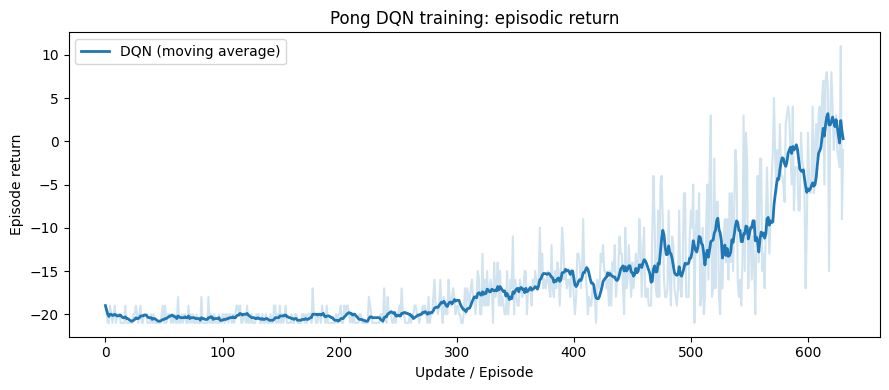

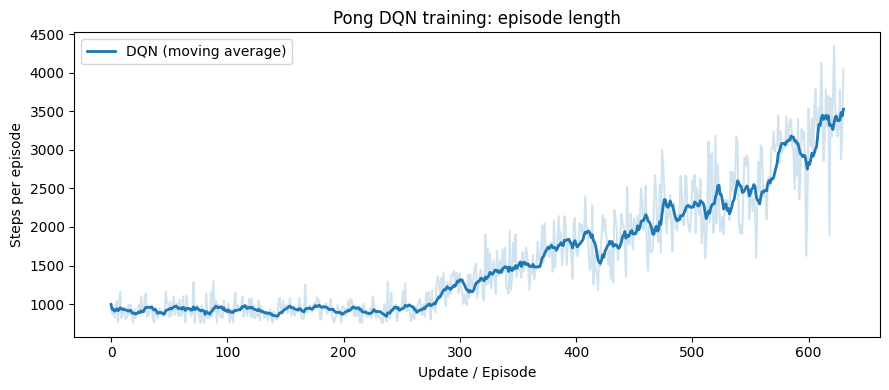

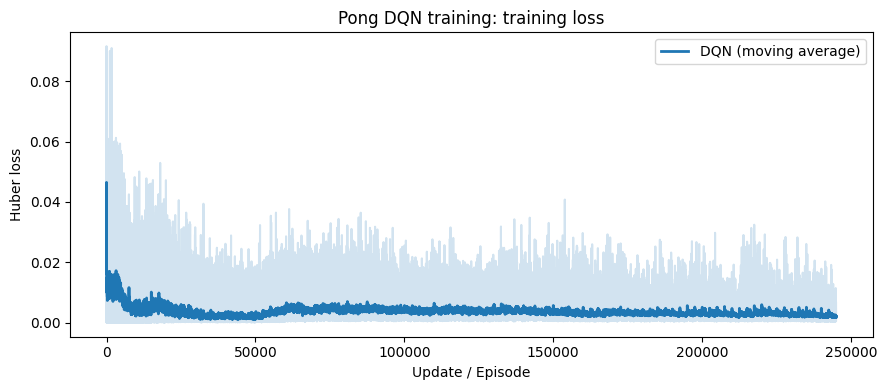

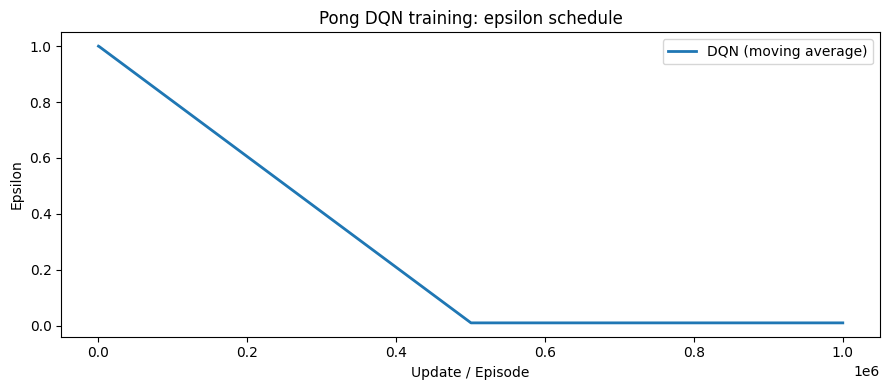

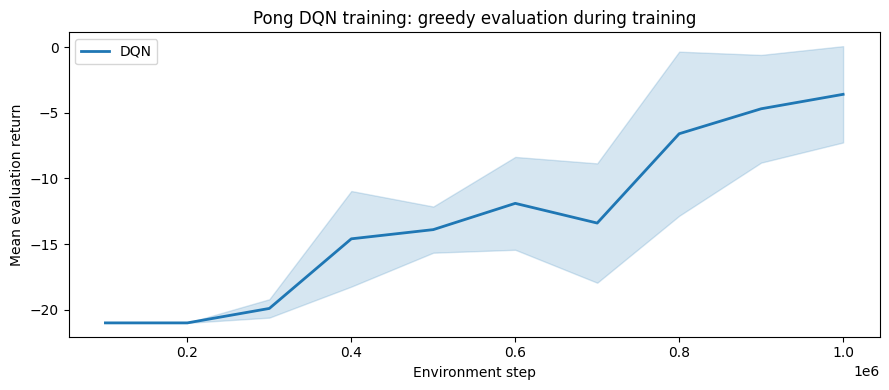

Final independent greedy evaluation: {'returns': array([ 3., -7.,  3.,  3., -7., -3., -7., -6., -3., -3.]), 'lengths': array([4000., 3630., 4000., 4000., 3627., 4000., 3625., 4000., 4000.,
       4000.]), 'mean_return': -2.7, 'std_return': 4.050925820105819, 'mean_length': 3888.2, 'std_length': 170.7810293914403}
Example trained rollout: {'gif_path': 'assets/cell_outputs/pong_dqn_policy.gif', 'total_return': 3.0, 'steps_executed': 4000}



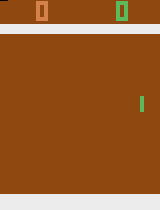

In [19]:
# Run this when you are ready for the long DQN training job:
dqn_run = run_pong_dqn_training(training_config)


In [23]:
# Save trained DQN weights
checkpoint_path = ASSET_ROOT / "pong_dqn_checkpoint.pt"

torch.save(
    {
        "online_net_state_dict": dqn_run["online_net"].state_dict(),
        "target_net_state_dict": dqn_run["target_net"].state_dict(),
        "training_config": training_config,
        "final_eval": dqn_run.get("final_eval", None),
    },
    checkpoint_path,
)

print("Saved checkpoint to:", checkpoint_path)


Saved checkpoint to: assets/cell_outputs/pong_dqn_checkpoint.pt


These outputs should be read in three layers. The training plots show whether the DQN pipeline is internally behaving well: episodic return and episode length tell us whether the agent is moving away from random play, the loss curve shows whether the Bellman updates stay numerically stable, and the epsilon schedule shows how quickly exploration is being reduced. The evaluation curve is stricter. Each point comes from several independent greedy episodes, and the shaded band shows the standard deviation across those episodes. That is the number to trust when we want a less fragile picture of progress, because it is much harder to cherry-pick than a single rollout. The final gameplay GIF then closes the loop qualitatively: after the plots suggest that the policy is improving, the rollout lets us check whether the paddle movement on screen also looks more purposeful than random play.

## From DQN to Double DQN

Standard DQN already uses a target network, but it can still systematically **overestimate** action values. The reason is subtle but important. In the bootstrap target, the same set of next-state value estimates is used both to decide which action looks best and to measure how good that chosen action is. When those estimates are noisy, the max operator tends to pick actions whose value was overestimated by chance. That optimistic error then enters the target and can be reinforced over many updates.

In standard DQN, the non-terminal target is written as

$$
y_{\text{DQN}} = r + \gamma \max_{a'} Q_{\text{target}}(s', a'; \theta^-)
$$

Even though the target network is more stable than the online network, the same target values are still doing two jobs at once: they select the maximizing action and they provide the value of that action. That is exactly the coupling that creates overestimation bias.

Double DQN keeps the whole DQN pipeline intact and changes only this one step. The two networks now play different roles. The **online network** chooses the next action index, and the **target network** evaluates that chosen action. So the Double DQN target becomes

$$
a^* = \arg\max_{a'} Q_{\text{online}}(s', a'; \theta)
$$

$$
y_{\text{Double DQN}} = r + \gamma Q_{\text{target}}(s', a^*; \theta^-)
$$

So the online network answers the question "which action looks best next?" while the target network answers the question "what is that chosen action worth?" This separation makes the target less optimistic and usually more reliable.

That is why Double DQN is such a useful first improvement. Nothing else in the training loop has to change: replay, convolutional features, epsilon-greedy behavior, and target-network synchronization all remain the same. We only make the bootstrap target better. Pedagogically, that is ideal, because it lets us see how much of DQN's behavior is controlled by target construction alone.

### Task 4

**Implement the Double DQN target (10-15 min)**

Only the target computation changes here. The online network should choose the best next action, but the target network should evaluate that chosen action. This separates action selection from action evaluation and reduces the overestimation bias of standard DQN.

The rest of the training step and the replay logic remain unchanged. That is exactly why Double DQN is a useful first improvement: the algorithmic change is small, but its effect on stability can be meaningful.

In [24]:
def compute_double_dqn_targets(
    *,
    rewards: torch.Tensor,
    dones: torch.Tensor,
    next_obs: torch.Tensor,
    online_net: nn.Module,
    target_net: nn.Module,
    gamma: float,
) -> torch.Tensor:
########################################################################
    with torch.no_grad():
        next_actions = torch.argmax(online_net(next_obs), dim=1)
        next_q = target_net(next_obs).gather(1, next_actions.unsqueeze(1)).squeeze(1)
        return rewards + gamma * (1.0 - dones) * next_q
########################################################################

In [25]:
def compare_dqn_and_double_dqn(config: dict = training_config):
    comparison_runs = {}
    for label, target_builder in {
        'DQN': compute_dqn_targets,
        'Double DQN': compute_double_dqn_targets,
    }.items():
        train_env = s7u.make_pong_env(seed=SEED)
        model = QNetwork(obs_shape=train_env.observation_space.shape, num_actions=train_env.action_space.n).to(DEVICE)
        target_model = QNetwork(obs_shape=train_env.observation_space.shape, num_actions=train_env.action_space.n).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
        buffer = ReplayBuffer(config['replay_capacity'], train_env.observation_space.shape, DEVICE)

        run = train_dqn(
            train_env,
            model,
            target_model,
            optimizer,
            buffer,
            total_steps=config['total_steps'],
            batch_size=config['batch_size'],
            learning_starts=config['learning_starts'],
            train_frequency=config['train_frequency'],
            target_update_frequency=config['target_update_frequency'],
            gamma=config['gamma'],
            epsilon_start=config['epsilon_start'],
            epsilon_end=config['epsilon_end'],
            epsilon_decay_steps=config['epsilon_decay_steps'],
            eval_frequency=config['eval_frequency'],
            eval_episodes=config['eval_episodes'],
            eval_max_steps=config['eval_max_steps'],
            target_builder_fn=target_builder,
            progress=config.get('progress', True),
            progress_label=label,
        )
        train_env.close()
        comparison_runs[label] = run

    s7u.plot_many_curves({label: run['returns'] for label, run in comparison_runs.items()}, title='Pong: DQN versus Double DQN return', ylabel='Episode return', window=10)
    s7u.plot_many_curves({label: run['lengths'] for label, run in comparison_runs.items()}, title='Pong: DQN versus Double DQN episode length', ylabel='Steps per episode', window=10)
    s7u.plot_many_curves({label: run['losses'] for label, run in comparison_runs.items()}, title='Pong: DQN versus Double DQN loss', ylabel='Huber loss', window=50)
    s7u.plot_evaluation_curves(
        {
            label: {
                'steps': run['evaluation_steps'],
                'means': run['evaluation_mean_returns'],
                'stds': run['evaluation_std_returns'],
            }
            for label, run in comparison_runs.items()
        },
        title='Pong: DQN versus Double DQN greedy evaluation',
        ylabel='Mean evaluation return',
    )

    comparison_gifs = []
    for label, run in comparison_runs.items():
        final_eval = evaluate_q_network(
            run['online_net'],
            device=DEVICE,
            n_episodes=10,
            seed=SEED,
            max_steps=config['eval_max_steps'],
        )
        run['final_eval'] = final_eval
        print(label, 'final independent greedy evaluation:', final_eval)

        gif = s7u.export_atari_policy_gif(
            run['online_net'],
            device=DEVICE,
            output_dir=ASSET_ROOT,
            gif_name=f'pong_{label.lower().replace(" ", "_")}_policy.gif',
            seed=SEED,
            max_steps=config.get('rollout_max_steps', config['eval_max_steps']),
            fps=20.0,
        )
        print(label, 'trained gameplay:', gif)
        run['policy_gif'] = gif
        comparison_gifs.append({'title': label, 'gif_path': gif['gif_path']})

    display(s7u.render_side_by_side_gifs(comparison_gifs, width=360))
    return comparison_runs


In [30]:
training_config = {
    'total_steps': 2_000_000,
    'batch_size': 32,
    'learning_starts': 50_000,
    'train_frequency': 4,
    'target_update_frequency': 10_000,
    'gamma': 0.99,
    'epsilon_start': 1.0,
    'epsilon_end': 0.01,
    'epsilon_decay_steps': 1_000_000,
    'eval_frequency': 200_000,
    'eval_episodes': 5,
    'eval_max_steps': 10_000,
    'rollout_max_steps': 6_000,
    'replay_capacity': 50_000,
    'learning_rate': 1e-4,
    'progress': True,
}


In [ ]:
# Run this when you are ready for the DQN vs Double DQN comparison:
comparison_runs = compare_dqn_and_double_dqn(training_config)


In [ ]:
# Save all trained comparison weights
for label, run in comparison_runs.items():
    safe_label = label.lower().replace(" ", "_").replace("-", "_")
    checkpoint_path = ASSET_ROOT / f"pong_{safe_label}_checkpoint.pt"

    torch.save(
        {
            "online_net_state_dict": run["online_net"].state_dict(),
            "target_net_state_dict": run["target_net"].state_dict(),
            "training_config": training_config,
            "final_eval": run.get("final_eval", None),
        },
        checkpoint_path,
    )

    print(f"Saved {label} checkpoint to:", checkpoint_path)


This comparison should be read in three layers. The training curves show what happens inside optimization: whether one target rule leads to faster reward improvement, shorter episodes, or cleaner Bellman updates. The evaluation curve is the more careful protocol. At each checkpoint, the current greedy policy is tested on several independent episodes, and the mean return is shown together with its standard deviation. That is important, because it reduces the temptation to trust one lucky episode or one visually pleasing rollout. Finally, the trained gameplay GIFs translate the curves back into behavior on the screen. If Double DQN looks smoother in evaluation or produces a more coherent final policy, that difference comes from one specific change: the online network selects the next action, while the target network evaluates the value of that chosen action.